# Orion vs MPS vs Ideal (RTX6000)

This notebook compares three modes:
- **Orion**: `results/orion/*_{be,hp}.json` (per-client files)
- **MPS baseline**: `results/mps/*.json` (single file with `*-0`/`*-1` metrics)
- **Ideal (isolated)**: `results/ideal/*_hp.json` (one model running alone)

Terminology:
- **BE** = best-effort client
- **HP** = high-priority client

Conventions used in this repo’s scripts (this notebook follows them):
- Orion filenames: `BE_HP_<run>_{be,hp}.json`
- MPS filenames: `HP_BE_<run>.json`
- For MPS JSONs: `*-0` corresponds to **HP** (model0), `*-1` corresponds to **BE** (model1).

Ideal results are *per-model*, so we normalize BE/HP metrics by the isolated run of the same model.

In [74]:
import json
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

BASE = Path('.')
ORION_DIR = BASE / 'results' / 'orion'
MPS_DIR = BASE / 'results' / 'mps'
IDEAL_DIR = BASE / 'results' / 'ideal'
PAPER_PDF = Path('../../2024_Orion- Interference-aware, Fine-grained GPU Sharing for ML Applications.pdf')

assert ORION_DIR.exists(), f'Missing {ORION_DIR}'
assert MPS_DIR.exists(), f'Missing {MPS_DIR}'
assert IDEAL_DIR.exists(), f'Missing {IDEAL_DIR}'

print('Orion jsons:', len(list(ORION_DIR.glob('*.json'))))
print('MPS jsons  :', len(list(MPS_DIR.glob('*.json'))))
print('Ideal jsons:', len(list(IDEAL_DIR.glob('*.json'))))
print('Paper PDF  :', PAPER_PDF.exists())

Orion jsons: 32
MPS jsons  : 16
Ideal jsons: 4
Paper PDF  : True


In [75]:
def _load_json(path: Path) -> dict:
    with path.open() as f:
        return json.load(f)

def _orion_metrics(d: dict) -> dict:
    return {
        'throughput': d.get('throughput'),
        'p50': d.get('p50_latency'),
        'p95': d.get('p95_latency'),
        'p99': d.get('p99_latency'),
    }

def _mps_metrics(d: dict, idx: int) -> dict:
    # idx 0 = model0/HP; idx 1 = model1/BE (see gather_results.py)
    return {
        'throughput': d.get(f'throughput-{idx}'),
        'p50': d.get(f'p50-latency-{idx}'),
        'p95': d.get(f'p95-latency-{idx}'),
        'p99': d.get(f'p99-latency-{idx}'),
    }

def _ideal_metrics(d: dict) -> dict:
    # Ideal results have the same schema as Orion per-client jsons
    return _orion_metrics(d)

def load_orion() -> pd.DataFrame:
    rows = []
    pat = re.compile(r'(.+?)_(.+?)_(\d+)_(be|hp)\.json$')
    for p in ORION_DIR.glob('*.json'):
        m = pat.match(p.name)
        if not m:
            continue
        be, hp, run, kind = m.group(1), m.group(2), int(m.group(3)), m.group(4)
        d = _load_json(p)
        met = _orion_metrics(d)
        rows.append({
            'be_model': be,
            'hp_model': hp,
            'run': run,
            'client': kind,
            **{f'orion_{k}': v for k, v in met.items()},
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('No Orion results parsed')
    return df

def load_mps() -> pd.DataFrame:
    rows = []
    # MPS filenames are HP_BE_<run>.json in this repo’s scripts
    pat = re.compile(r'(.+?)_(.+?)_(\d+)\.json$')
    for p in MPS_DIR.glob('*.json'):
        m = pat.match(p.name)
        if not m:
            continue
        hp, be, run = m.group(1), m.group(2), int(m.group(3))
        d = _load_json(p)
        m_hp = _mps_metrics(d, 0)
        m_be = _mps_metrics(d, 1)
        rows.append({
            'be_model': be,
            'hp_model': hp,
            'run': run,
            **{f'mps_be_{k}': v for k, v in m_be.items()},
            **{f'mps_hp_{k}': v for k, v in m_hp.items()},
            'mps_duration': d.get('duration'),
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('No MPS results parsed')
    return df

def load_ideal() -> pd.DataFrame:
    rows = []
    pat = re.compile(r'(.+?)_(\d+)_hp\.json$')
    for p in IDEAL_DIR.glob('*.json'):
        m = pat.match(p.name)
        if not m:
            continue
        model, run = m.group(1), int(m.group(2))
        d = _load_json(p)
        met = _ideal_metrics(d)
        rows.append({
            'model': model,
            'run': run,
            **{f'ideal_{k}': v for k, v in met.items()},
        })
    df = pd.DataFrame(rows)
    if df.empty:
        raise RuntimeError('No Ideal results parsed')
    return df

orion_raw = load_orion()
mps_raw = load_mps()
ideal_raw = load_ideal()

print('Orion rows:', len(orion_raw))
print('MPS rows  :', len(mps_raw))
print('Ideal rows:', len(ideal_raw))
display(ideal_raw.sort_values(['model','run']))

Orion rows: 32
MPS rows  : 16
Ideal rows: 4


,model,run,ideal_throughput,ideal_p50,ideal_p95,ideal_p99
3,BERT,0,17.928219,23273.697853,44663.661587,46419.062402
0,MobileNetV2,0,150.063218,7858.678341,15394.974875,16141.402295
2,ResNet101,0,58.163509,17950.886846,34605.548847,36067.379487
1,ResNet50,0,101.185428,22358.194470,43449.604106,45434.115477


In [76]:
# Pivot Orion to one row per (be_model, hp_model, run) with separate BE/HP columns
orion_be = (orion_raw[orion_raw['client'] == 'be']
           .drop(columns=['client'])
           .rename(columns={
               'orion_throughput': 'orion_be_throughput',
               'orion_p50': 'orion_be_p50',
               'orion_p95': 'orion_be_p95',
               'orion_p99': 'orion_be_p99',
           }))
orion_hp = (orion_raw[orion_raw['client'] == 'hp']
           .drop(columns=['client'])
           .rename(columns={
               'orion_throughput': 'orion_hp_throughput',
               'orion_p50': 'orion_hp_p50',
               'orion_p95': 'orion_hp_p95',
               'orion_p99': 'orion_hp_p99',
           }))

df = orion_be.merge(orion_hp, on=['be_model','hp_model','run'], how='inner')
df = df.merge(mps_raw, on=['be_model','hp_model','run'], how='inner')

# Ideal: average across runs (per model) and map onto BE/HP roles
ideal_mean = ideal_raw.groupby('model', as_index=True).mean(numeric_only=True)

def _map_ideal(series: pd.Series, col: str) -> pd.Series:
    return series.map(ideal_mean[col].to_dict())

df['ideal_be_throughput'] = _map_ideal(df['be_model'], 'ideal_throughput')
df['ideal_be_p50'] = _map_ideal(df['be_model'], 'ideal_p50')
df['ideal_be_p95'] = _map_ideal(df['be_model'], 'ideal_p95')
df['ideal_be_p99'] = _map_ideal(df['be_model'], 'ideal_p99')

df['ideal_hp_throughput'] = _map_ideal(df['hp_model'], 'ideal_throughput')
df['ideal_hp_p50'] = _map_ideal(df['hp_model'], 'ideal_p50')
df['ideal_hp_p95'] = _map_ideal(df['hp_model'], 'ideal_p95')
df['ideal_hp_p99'] = _map_ideal(df['hp_model'], 'ideal_p99')

missing_ideal = df[df[['ideal_be_throughput','ideal_hp_throughput']].isna().any(axis=1)]
if not missing_ideal.empty:
    display(missing_ideal[['be_model','hp_model']].drop_duplicates())
    raise RuntimeError('Missing ideal data for some models; re-run run_ideal.py for those models')

# Totals and ratios
df['orion_total_throughput'] = df['orion_be_throughput'] + df['orion_hp_throughput']
df['mps_total_throughput'] = df['mps_be_throughput'] + df['mps_hp_throughput']
df['ideal_total_throughput'] = df['ideal_be_throughput'] + df['ideal_hp_throughput']

df['orion_total_efficiency'] = df['orion_total_throughput'] / df['ideal_total_throughput']
df['mps_total_efficiency'] = df['mps_total_throughput'] / df['ideal_total_throughput']

# HP protection: p95 slowdown relative to isolated (Ideal)
df['orion_hp_p95_slowdown'] = df['orion_hp_p95'] / df['ideal_hp_p95']
df['mps_hp_p95_slowdown'] = df['mps_hp_p95'] / df['ideal_hp_p95']

# BE cost: throughput fraction of isolated
df['orion_be_thr_frac_of_ideal'] = df['orion_be_throughput'] / df['ideal_be_throughput']
df['mps_be_thr_frac_of_ideal'] = df['mps_be_throughput'] / df['ideal_be_throughput']

df = df.sort_values(['be_model','hp_model','run']).reset_index(drop=True)
df[['be_model','hp_model','ideal_total_throughput','orion_total_throughput','mps_total_throughput','orion_total_efficiency','mps_total_efficiency']].head(10)

,be_model,hp_model,ideal_total_throughput,orion_total_throughput,mps_total_throughput,orion_total_efficiency,mps_total_efficiency
0,BERT,BERT,35.856437,18.067536,19.218640,0.503885,0.535989
1,BERT,MobileNetV2,167.991436,146.218851,67.672038,0.870395,0.402830
2,BERT,ResNet101,76.091728,57.950668,32.395981,0.761590,0.425749
3,BERT,ResNet50,119.113646,98.503186,49.484356,0.826968,0.415438
4,MobileNetV2,BERT,167.991436,18.709400,67.846018,0.111371,0.403866
5,MobileNetV2,MobileNetV2,300.126435,164.049113,171.233619,0.546600,0.570538
6,MobileNetV2,ResNet101,208.226727,62.259582,122.804681,0.298999,0.589764
7,MobileNetV2,ResNet50,251.248645,105.168003,143.517480,0.418581,0.571217
8,ResNet101,BERT,76.091728,18.236885,32.388862,0.239670,0.425655
9,ResNet101,MobileNetV2,208.226727,153.821316,122.728444,0.738720,0.589398


## Figure 1: Total throughput efficiency vs Ideal
We normalize the total throughput by `Ideal(BE) + Ideal(HP)`. Higher is better.

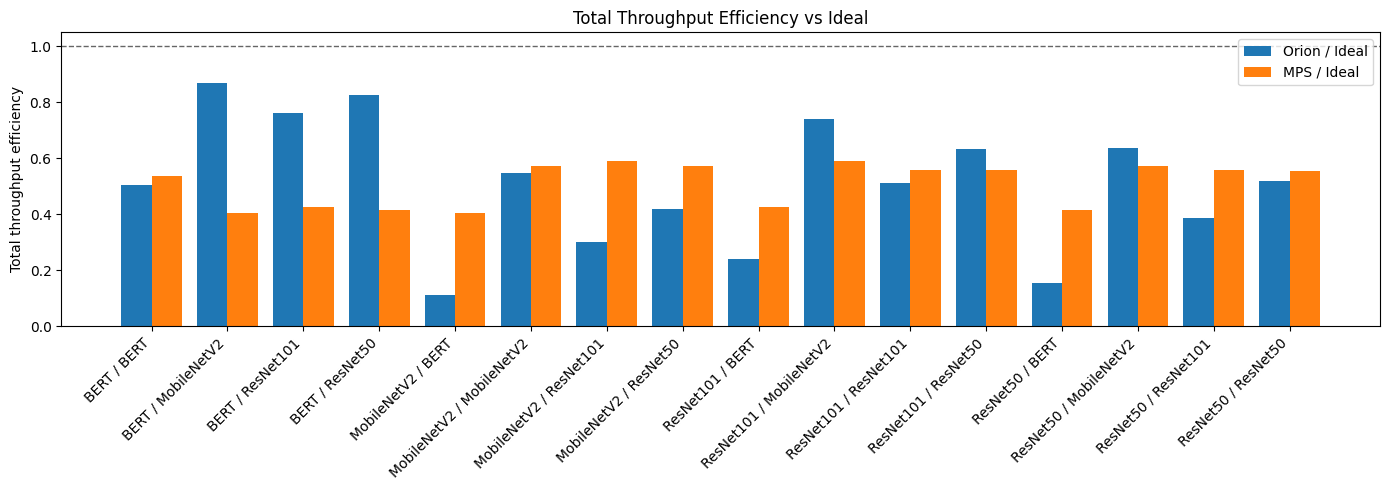

In [77]:
plot_df = df.copy()
plot_df['pair'] = plot_df['be_model'] + ' / ' + plot_df['hp_model']
plot_df = plot_df.sort_values('pair')

x = range(len(plot_df))
w = 0.4
plt.figure(figsize=(14, 5))
plt.bar([i - w/2 for i in x], plot_df['orion_total_efficiency'], width=w, label='Orion / Ideal')
plt.bar([i + w/2 for i in x], plot_df['mps_total_efficiency'], width=w, label='MPS / Ideal')
plt.axhline(1.0, linestyle='--', linewidth=1, color='black', alpha=0.6)
plt.xticks(list(x), plot_df['pair'], rotation=45, ha='right')
plt.ylabel('Total throughput efficiency')
plt.title('Total Throughput Efficiency vs Ideal')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 2: HP p95 slowdown vs Ideal
Lower is better for HP. A value of 1.0 means HP matches isolated performance.

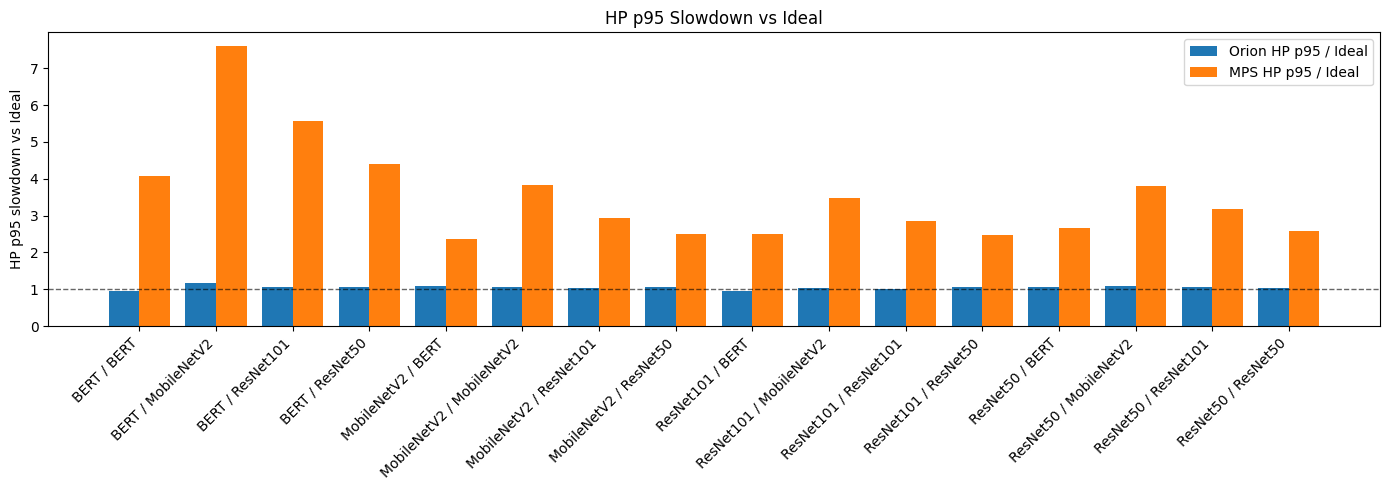

In [78]:
plot_df = df.copy()
plot_df['pair'] = plot_df['be_model'] + ' / ' + plot_df['hp_model']
plot_df = plot_df.sort_values('pair')

x = range(len(plot_df))
w = 0.4
plt.figure(figsize=(14, 5))
plt.bar([i - w/2 for i in x], plot_df['orion_hp_p95_slowdown'], width=w, label='Orion HP p95 / Ideal')
plt.bar([i + w/2 for i in x], plot_df['mps_hp_p95_slowdown'], width=w, label='MPS HP p95 / Ideal')
plt.axhline(1.0, linestyle='--', linewidth=1, color='black', alpha=0.6)
plt.xticks(list(x), plot_df['pair'], rotation=45, ha='right')
plt.ylabel('HP p95 slowdown vs Ideal')
plt.title('HP p95 Slowdown vs Ideal')
plt.legend()
plt.tight_layout()
plt.show()

## Figure 3: Tradeoff view (HP protection vs BE progress)
x-axis: BE throughput fraction of isolated (Ideal). Higher is better for BE.
y-axis: HP p95 slowdown vs isolated (Ideal). Lower is better for HP.

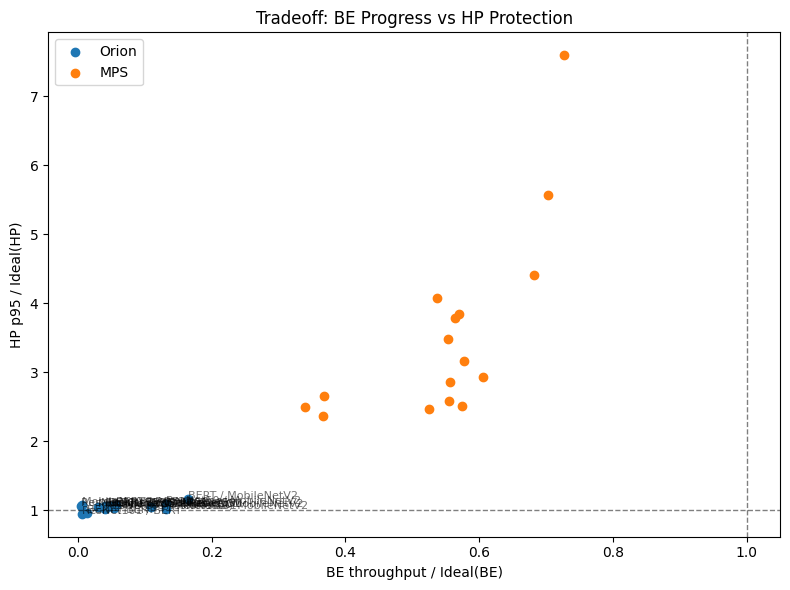

In [79]:
plot_df = df.copy()
plot_df['pair'] = plot_df['be_model'] + ' / ' + plot_df['hp_model']

plt.figure(figsize=(8, 6))
plt.scatter(plot_df['orion_be_thr_frac_of_ideal'], plot_df['orion_hp_p95_slowdown'], label='Orion')
plt.scatter(plot_df['mps_be_thr_frac_of_ideal'], plot_df['mps_hp_p95_slowdown'], label='MPS')

for _, r in plot_df.iterrows():
    plt.annotate(r['pair'], (r['orion_be_thr_frac_of_ideal'], r['orion_hp_p95_slowdown']), fontsize=8, alpha=0.55)

plt.axhline(1.0, linestyle='--', linewidth=1, color='black', alpha=0.5)
plt.axvline(1.0, linestyle='--', linewidth=1, color='black', alpha=0.5)
plt.xlabel('BE throughput / Ideal(BE)')
plt.ylabel('HP p95 / Ideal(HP)')
plt.title('Tradeoff: BE Progress vs HP Protection')
plt.legend()
plt.tight_layout()
plt.show()

## Export a summary CSV
Use this to plot externally or archive results.

In [80]:
out = BASE / 'orion_vs_mps_vs_ideal_summary.csv'
df.to_csv(out, index=False)
print('Wrote', out.resolve())

cols = [
    'be_model','hp_model',
    'ideal_be_throughput','ideal_hp_throughput','ideal_total_throughput',
    'orion_be_throughput','orion_hp_throughput','orion_total_throughput','orion_total_efficiency',
    'mps_be_throughput','mps_hp_throughput','mps_total_throughput','mps_total_efficiency',
    'orion_be_thr_frac_of_ideal','mps_be_thr_frac_of_ideal',
    'orion_hp_p95_slowdown','mps_hp_p95_slowdown',
    'orion_hp_p95','mps_hp_p95','ideal_hp_p95',
    'orion_be_p95','mps_be_p95','ideal_be_p95',
 ]
display(df[cols].sort_values(['be_model','hp_model']))

Wrote /home/cc/orion/rtx6000_results/inf_inf_updated/orion_vs_mps_vs_ideal_summary.csv


,be_model,hp_model,ideal_be_throughput,ideal_hp_throughput,ideal_total_throughput,orion_be_throughput,orion_hp_throughput,orion_total_throughput,orion_total_efficiency,mps_be_throughput,...,orion_be_thr_frac_of_ideal,mps_be_thr_frac_of_ideal,orion_hp_p95_slowdown,mps_hp_p95_slowdown,orion_hp_p95,mps_hp_p95,ideal_hp_p95,orion_be_p95,mps_be_p95,ideal_be_p95
0,BERT,BERT,17.928219,17.928219,35.856437,0.256153,17.811383,18.067536,0.503885,9.621277,...,0.014288,0.536656,0.963509,4.075562,43033.843839,182029.531717,44663.661587,166293.596220,181935.571384,44663.661587
1,BERT,MobileNetV2,17.928219,150.063218,167.991436,2.946598,143.272253,146.218851,0.870395,13.025837,...,0.164355,0.726555,1.165832,7.593370,17947.954130,116899.740148,15394.974875,55176.697302,76378.803658,44663.661587
2,BERT,ResNet101,17.928219,58.163509,76.091728,0.801706,57.148962,57.950668,0.761590,12.609693,...,0.044718,0.703343,1.066448,5.566475,36905.026996,192630.938601,34605.548847,83291.086793,118492.096186,44663.661587
3,BERT,ResNet50,17.928219,101.185428,119.113646,1.028818,97.474368,98.503186,0.826968,12.233933,...,0.057385,0.682384,1.072513,4.408620,46600.259829,191552.783835,43449.604106,88190.205765,119463.683009,44663.661587
4,MobileNetV2,BERT,150.063218,17.928219,167.991436,0.876720,17.832681,18.709400,0.111371,54.896318,...,0.005842,0.365821,1.075810,2.360872,48049.634802,105445.202076,44663.661587,156802.261305,159984.809172,15394.974875
5,MobileNetV2,MobileNetV2,150.063218,150.063218,300.126435,16.446183,147.602930,164.049113,0.546600,85.618841,...,0.109595,0.570552,1.051447,3.842982,16187.006474,59162.612855,15394.974875,54453.750813,59169.649482,15394.974875
6,MobileNetV2,ResNet101,150.063218,58.163509,208.226727,4.513187,57.746395,62.259582,0.298999,90.824035,...,0.030075,0.605238,1.042145,2.926465,36063.983953,101271.933639,34605.548847,80397.941804,81815.246201,15394.974875
7,MobileNetV2,ResNet50,150.063218,101.185428,251.248645,6.626462,98.541541,105.168003,0.418581,86.071349,...,0.044158,0.573567,1.050033,2.512217,45623.523390,109154.855561,43449.604106,85498.976910,87397.331810,15394.974875
8,ResNet101,BERT,58.163509,17.928219,76.091728,0.352893,17.883992,18.236885,0.239670,19.773113,...,0.006067,0.339957,0.949845,2.491076,42423.546207,111260.576534,44663.661587,160881.441855,181097.180724,34605.548847
9,ResNet101,MobileNetV2,58.163509,150.063218,208.226727,7.695603,146.125712,153.821316,0.738720,32.215993,...,0.132310,0.553887,1.024358,3.485386,15769.968712,53657.432699,15394.974875,55280.537713,65352.332163,34605.548847


## Paper comparison helper (EuroSys'24 Orion PDF)
This section extracts a *small* set of numeric “×” claims and a few lines mentioning tail latency from the paper PDF, to help you line up which published figure/result to compare against. It’s meant for quick navigation, not full reproduction of paper content.

In [81]:
# If you get an import error, run: pip install pymupdf
import re
from pathlib import Path

paper_path = PAPER_PDF.resolve()
print('paper_path:', paper_path)
assert paper_path.exists(), 'Paper PDF not found'

try:
    import fitz  # PyMuPDF
except Exception as e:
    raise RuntimeError('PyMuPDF not available. Install with: pip install pymupdf') from e

doc = fitz.open(str(paper_path))
print('pages:', doc.page_count)

hits = []
for i in range(doc.page_count):
    text = doc.load_page(i).get_text('text')
    # Extract a few “x” claims like 7.3×
    for m in re.finditer(r'(\d+(?:\.\d+)?)\s*×', text):
        val = float(m.group(1))
        start = max(0, m.start() - 60)
        end = min(len(text), m.end() + 60)
        ctx = re.sub(r'\s+', ' ', text[start:end]).strip()
        hits.append({'page': i+1, 'multiplier_x': val, 'context': ctx[:140]})
    # Extract tail-latency mentions (keep short context)
    for m in re.finditer(r'tail latency', text, flags=re.IGNORECASE):
        start = max(0, m.start() - 60)
        end = min(len(text), m.end() + 60)
        ctx = re.sub(r'\s+', ' ', text[start:end]).strip()
        hits.append({'page': i+1, 'multiplier_x': None, 'context': ctx[:140]})

paper_df = pd.DataFrame(hits)
print('extracted snippets:', len(paper_df))
display(paper_df.sort_values(['multiplier_x','page'], ascending=[False, True]).head(30))

paper_path: /home/cc/orion/2024_Orion- Interference-aware, Fine-grained GPU Sharing for ML Applications.pdf
pages: 18
extracted snippets: 49


,page,multiplier_x,context
0,1,7.30,erence jobs to increase per-GPU request throug...
3,2,7.30,"ine inference, Orion improves aggregate throug..."
38,12,7.30,- gregate inference throughput by up to 2× (fo...
10,9,3.44,"ffort training job. On average, REEF’s inferen..."
13,10,3.00,"nference job within 14% of the ideal latency, ..."
12,10,2.50,otal throughput. ideal for the Apollo trace ex...
4,2,2.30,- age while increasing the GPU’s aggregate thr...
15,10,2.30,"ime, Orion increases aggregate throughput by u..."
40,12,2.20,y is 3 orders of magnitude higher than ideal)....
37,12,2.00,while increasing ag- gregate inference through...


## Paper-style figures (same outputs as `plot_*.py`)
This section reproduces the existing plotting scripts in this folder (throughput bars, HP p95 latency bars, and MPS-vs-Ideal comparison + slowdown heatmap) directly from the JSON outputs under `results/`.

It also writes the same intermediate CSVs (`results/*_latency.csv`, `results/*_{be,hp}_throughput.csv`) so you can still run the standalone scripts if desired.

In [ ]:
# Paper-style section setup (self-contained; safe to run in a fresh kernel)
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE = globals().get('BASE', Path('.'))
MODELS = ['ResNet50', 'MobileNetV2', 'ResNet101', 'BERT']
results_dir = BASE / 'results'
results_dir.mkdir(parents=True, exist_ok=True)

# Latency unit note: the result JSONs in this repo report latencies in microseconds.
# The paper plotting scripts label latency as ms, so we convert µs -> ms when building CSVs for plotting.
_LAT_US_TO_MS = 1.0 / 1000.0


def _mean_std_str(values: list[float]) -> str:
    if not values:
        return '0/0'
    arr = np.array(values, dtype=float)
    return f"{np.average(arr):.2f}/{np.std(arr):.2f}"


def _load_json_maybe(path: Path) -> dict | None:
    if not path.exists():
        return None
    try:
        with path.open() as f:
            return json.load(f)
    except Exception:
        return None


def _empty_matrix() -> pd.DataFrame:
    return pd.DataFrame('0/0', index=MODELS, columns=MODELS)


def _write_three(prefix: str, lat: pd.DataFrame, be_thr: pd.DataFrame, hp_thr: pd.DataFrame) -> None:
    lat.to_csv(results_dir / f'{prefix}_latency.csv')
    be_thr.to_csv(results_dir / f'{prefix}_be_throughput.csv')
    hp_thr.to_csv(results_dir / f'{prefix}_hp_throughput.csv')


def build_paper_matrices_from_disk(runs: list[int] | None = None) -> dict[str, dict[str, pd.DataFrame]]:
    """Rebuild the same CSV matrices used by gather_results.py/plot_*.py, directly from results JSONs."""
    if runs is None:
        runs = [0]

    mats: dict[str, dict[str, pd.DataFrame]] = {}

    # ---------------- Ideal (isolated) ----------------
    ideal_lat = _empty_matrix()
    ideal_be_thr = _empty_matrix()
    ideal_hp_thr = _empty_matrix()

    ideal_stats = {}
    for m in MODELS:
        thr_vals = []
        p95_vals_ms = []
        for p in (results_dir / 'ideal').glob(f'{m}_*_hp.json'):
            d = _load_json_maybe(p)
            if not d:
                continue
            if 'throughput' in d:
                thr_vals.append(float(d['throughput']))
            if 'p95_latency' in d:
                p95_vals_ms.append(float(d['p95_latency']) * _LAT_US_TO_MS)
        if not thr_vals or not p95_vals_ms:
            raise RuntimeError(f'Missing/empty Ideal results for {m} under {results_dir}/ideal')
        ideal_stats[m] = {
            'throughput_mean': float(np.mean(thr_vals)),
            'throughput_std': float(np.std(thr_vals)),
            'p95_mean_ms': float(np.mean(p95_vals_ms)),
            'p95_std_ms': float(np.std(p95_vals_ms)),
        }

    for be in MODELS:
        for hp in MODELS:
            ideal_lat.at[be, hp] = f"{ideal_stats[hp]['p95_mean_ms']:.2f}/{ideal_stats[hp]['p95_std_ms']:.2f}"
            ideal_hp_thr.at[be, hp] = f"{ideal_stats[hp]['throughput_mean']:.2f}/{ideal_stats[hp]['throughput_std']:.2f}"
            ideal_be_thr.at[be, hp] = f"{ideal_stats[be]['throughput_mean']:.2f}/{ideal_stats[be]['throughput_std']:.2f}"

    mats['ideal'] = {'latency': ideal_lat, 'be_throughput': ideal_be_thr, 'hp_throughput': ideal_hp_thr}
    _write_three('ideal', ideal_lat, ideal_be_thr, ideal_hp_thr)

    # ---------------- MPS / Streams (single JSON per pair) ----------------
    def _build_baseline_pairjson(prefix: str) -> None:
        bdir = results_dir / prefix
        if not bdir.exists():
            return
        lat = _empty_matrix()
        be_thr = _empty_matrix()
        hp_thr = _empty_matrix()
        for be in MODELS:
            for hp in MODELS:
                lat_vals_ms, be_thr_vals, hp_thr_vals = [], [], []
                for run in runs:
                    p = bdir / f'{hp}_{be}_{run}.json'  # HP first, then BE
                    d = _load_json_maybe(p)
                    if not d:
                        continue
                    # idx 0 = HP (model0), idx 1 = BE (model1)
                    v = d.get('p95-latency-0')
                    if v is not None:
                        lat_vals_ms.append(float(v) * _LAT_US_TO_MS)
                    v = d.get('throughput-0')
                    if v is not None:
                        hp_thr_vals.append(float(v))
                    v = d.get('throughput-1')
                    if v is not None:
                        be_thr_vals.append(float(v))
                lat.at[be, hp] = _mean_std_str(lat_vals_ms)
                hp_thr.at[be, hp] = _mean_std_str(hp_thr_vals)
                be_thr.at[be, hp] = _mean_std_str(be_thr_vals)
        mats[prefix] = {'latency': lat, 'be_throughput': be_thr, 'hp_throughput': hp_thr}
        _write_three(prefix, lat, be_thr, hp_thr)

    _build_baseline_pairjson('mps')
    _build_baseline_pairjson('streams')

    # ---------------- Orion/Temporal/REEF (per-client JSONs) ----------------
    def _build_orion_like(prefix: str) -> None:
        ddir = results_dir / prefix
        if not ddir.exists():
            return
        lat = _empty_matrix()
        be_thr = _empty_matrix()
        hp_thr = _empty_matrix()
        for be in MODELS:
            for hp in MODELS:
                lat_vals_ms, be_thr_vals, hp_thr_vals = [], [], []
                for run in runs:
                    d_hp = _load_json_maybe(ddir / f'{be}_{hp}_{run}_hp.json')
                    d_be = _load_json_maybe(ddir / f'{be}_{hp}_{run}_be.json')
                    if d_hp:
                        lat_vals_ms.append(float(d_hp.get('p95_latency')) * _LAT_US_TO_MS)
                        hp_thr_vals.append(float(d_hp.get('throughput')))
                    if d_be:
                        be_thr_vals.append(float(d_be.get('throughput')))
                lat.at[be, hp] = _mean_std_str(lat_vals_ms)
                hp_thr.at[be, hp] = _mean_std_str(hp_thr_vals)
                be_thr.at[be, hp] = _mean_std_str(be_thr_vals)
        mats[prefix] = {'latency': lat, 'be_throughput': be_thr, 'hp_throughput': hp_thr}
        _write_three(prefix, lat, be_thr, hp_thr)

    for p in ['orion', 'temporal', 'reef']:
        _build_orion_like(p)

    return mats


paper_mats = build_paper_matrices_from_disk()
print('Built matrices for:', sorted(paper_mats.keys()))

# Used by the plotting cells (match plot_*.py method naming)
method_order = ['Temporal', 'MPS', 'Streams', 'REEF', 'Orion', 'Ideal']
method2prefix = {
    'Temporal': 'temporal',
    'MPS': 'mps',
    'Streams': 'streams',
    'REEF': 'reef',
    'Orion': 'orion',
    'Ideal': 'ideal',
}
available_methods = [
    m for m in method_order
    if (results_dir / f"{method2prefix[m]}_latency.csv").exists()
    and (results_dir / f"{method2prefix[m]}_be_throughput.csv").exists()
    and (results_dir / f"{method2prefix[m]}_hp_throughput.csv").exists()
]
print('Available methods:', available_methods)

Built matrices for: ['ideal', 'mps', 'orion', 'reef', 'temporal']
Available methods: ['Temporal', 'MPS', 'REEF', 'Orion', 'Ideal']


In [83]:
# CSV parsing helpers for paper-style plots (self-contained)
def _parse_mean_series(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    df = df.drop(df.columns[0], axis=1)
    df.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df.at[r, c] = float(str(df.at[r, c]).split('/')[0])
    return df.mean()

def _parse_std_series(csv_path: Path) -> pd.Series:
    df = pd.read_csv(csv_path)
    df = df.drop(df.columns[0], axis=1)
    df.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df.at[r, c] = float(str(df.at[r, c]).split('/')[0])
    return df.std()

def _parse_mean_pair(csv_be: Path, csv_hp: Path) -> tuple[pd.Series, pd.Series]:
    df_be = pd.read_csv(csv_be)
    df_hp = pd.read_csv(csv_hp)
    df_be = df_be.drop(df_be.columns[0], axis=1)
    df_hp = df_hp.drop(df_hp.columns[0], axis=1)
    df_be.index = MODELS
    df_hp.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df_be.at[r, c] = float(str(df_be.at[r, c]).split('/')[0])
            df_hp.at[r, c] = float(str(df_hp.at[r, c]).split('/')[0])
    return df_be.mean(), df_hp.mean()

def _parse_std_pair(csv_be: Path, csv_hp: Path) -> tuple[pd.Series, pd.Series]:
    df_be = pd.read_csv(csv_be)
    df_hp = pd.read_csv(csv_hp)
    df_be = df_be.drop(df_be.columns[0], axis=1)
    df_hp = df_hp.drop(df_hp.columns[0], axis=1)
    df_be.index = MODELS
    df_hp.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df_be.at[r, c] = float(str(df_be.at[r, c]).split('/')[0])
            df_hp.at[r, c] = float(str(df_hp.at[r, c]).split('/')[0])
    return df_be.std(), df_hp.std()

print('Paper-style CSVs under:', results_dir.resolve())

Paper-style CSVs under: /home/cc/orion/rtx6000_results/inf_inf_updated/results


### Paper Figure: total throughput (stacked BE+HP)
This reproduces the stacked-bar plot saved by `plot_throughput.py` as `inf_inf_poisson_total_throughput.png`.

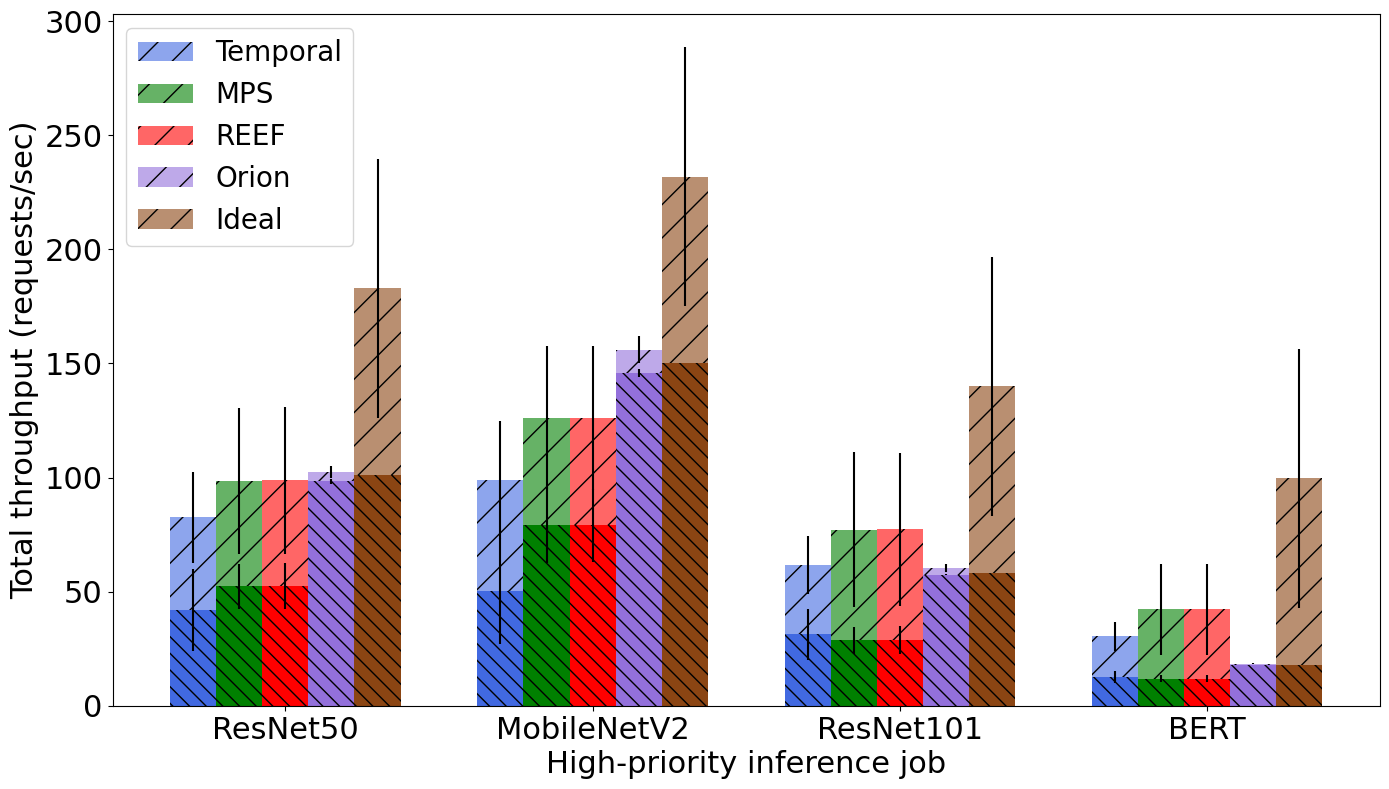

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_total_throughput.png


In [ ]:
from matplotlib import cm

results_dir = BASE / 'results'

# Match the script’s method ordering, but only keep those we have CSVs for.
method_order = ['Temporal', 'MPS', 'Streams', 'REEF', 'Orion', 'Ideal']
# method_order = ['MPS', 'Orion', 'Ideal']
method2prefix = {
    'Temporal': 'temporal',
    'MPS': 'mps',
    'Streams': 'streams',
    'REEF': 'reef',
    'Orion': 'orion',
    'Ideal': 'ideal',
}

available_methods = []
for m in method_order:
    prefix = method2prefix[m]
    be_csv = results_dir / f'{prefix}_be_throughput.csv'
    hp_csv = results_dir / f'{prefix}_hp_throughput.csv'
    if be_csv.exists() and hp_csv.exists():
        available_methods.append(m)

if not available_methods:
    raise RuntimeError('No throughput CSVs found under results/. Did matrix build run?')

colors = ['royalblue', 'darkorange', 'green', 'red', 'mediumpurple', 'saddlebrown']
width = 0.15 if len(available_methods) >= 4 else 0.25

fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(MODELS))

for method_id, method in enumerate(available_methods):
    prefix = method2prefix[method]
    be_csv = results_dir / f'{prefix}_be_throughput.csv'
    hp_csv = results_dir / f'{prefix}_hp_throughput.csv'
    be_mean, hp_mean = _parse_mean_pair(be_csv, hp_csv)
    be_std, hp_std = _parse_std_pair(be_csv, hp_csv)

    # Bottom = HP (hatch '\\'), then BE (hatch '/'), same as script.
    ax.bar(
        x + width * method_id, hp_mean.values, width, yerr=hp_std.values,
        align='edge', hatch='\\\\', color=colors[method_id % len(colors)]
    )
    ax.bar(
        x + width * method_id, be_mean.values, width, yerr=be_std.values,
        bottom=hp_mean.values, align='edge', hatch='/',
        color=colors[method_id % len(colors)], alpha=0.6, label=method
    )

x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=22)
plt.yticks(fontsize=22)
ax.set_ylabel('Total throughput (requests/sec)', fontsize=22)
ax.set_xlabel('High-priority inference job', fontsize=22)

plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', ncol=1, fontsize=20)

out_path = BASE / 'inf_inf_poisson_total_throughput.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_path.resolve())

### Paper Figure: HP p95 latency bars
This reproduces the multi-method HP latency comparison saved by `plot_latency.py` as `inf_inf_poisson_hp_latency.png`.

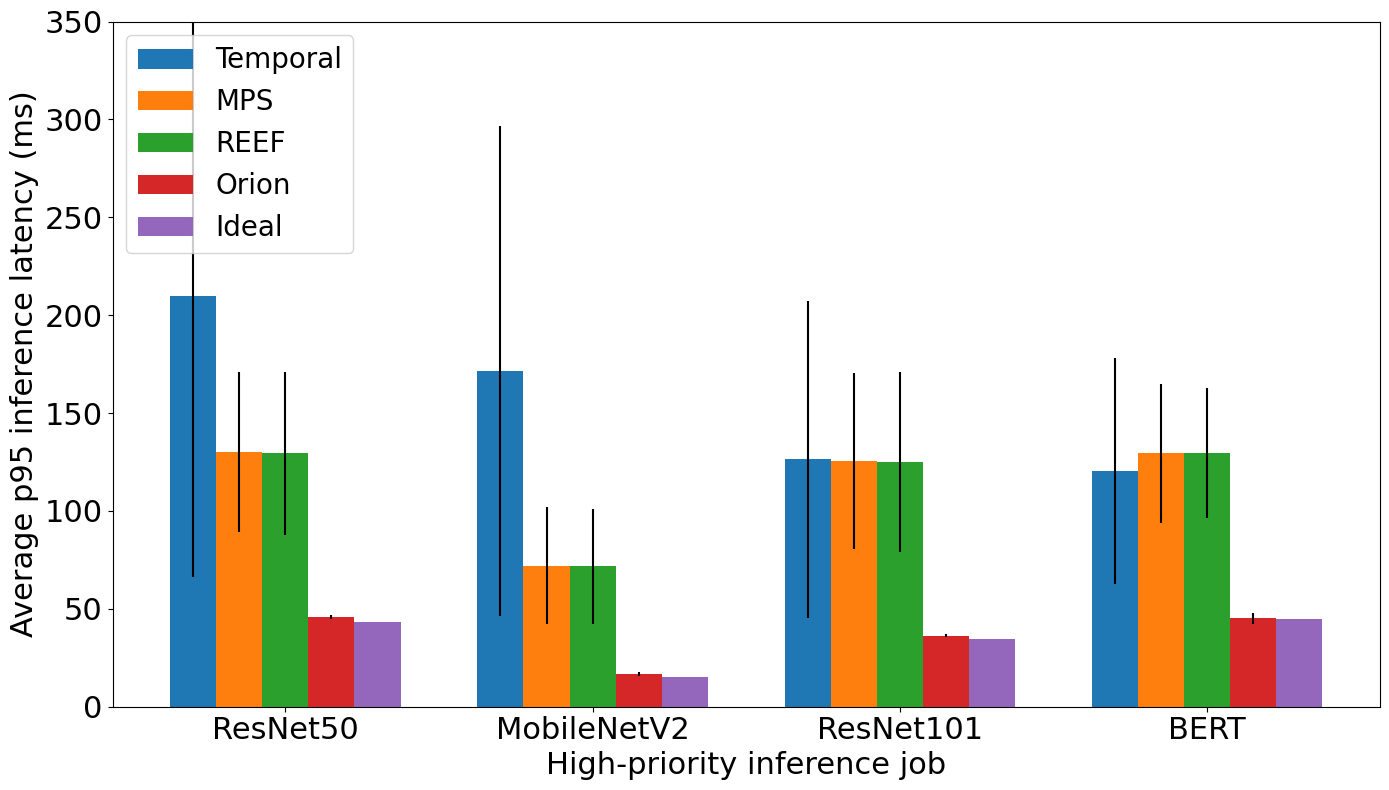

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_latency.png


In [85]:
fig, ax = plt.subplots(figsize=(14, 8))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25

for method_id, method in enumerate(available_methods):
    prefix = method2prefix[method]
    lat_csv = results_dir / f'{prefix}_latency.csv'
    if not lat_csv.exists():
        continue
    lat_mean = _parse_mean_series(lat_csv)
    lat_std = _parse_std_series(lat_csv)
    ax.bar(
        x + width * method_id, lat_mean.values, width,
        yerr=lat_std.values, align='edge', label=method
    )

x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=22)
plt.yticks(fontsize=22)
ax.set_ylim(0, 350)
ax.set_ylabel('Average p95 inference latency (ms)', fontsize=22)
ax.set_xlabel('High-priority inference job', fontsize=22)

plt.tight_layout()
handles, labels = ax.get_legend_handles_labels()
plt.legend(handles, labels, loc='upper left', ncol=1, fontsize=20)

out_path = BASE / 'inf_inf_poisson_hp_latency.png'
plt.savefig(out_path, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_path.resolve())

### Script-equivalent comparison: MPS vs Ideal
These reproduce `plot_comparison.py` outputs:
- `results/mps_vs_ideal_latency.png`
- `results/mps_vs_ideal_throughput.png`
- `results/mps_slowdown_heatmap.png`

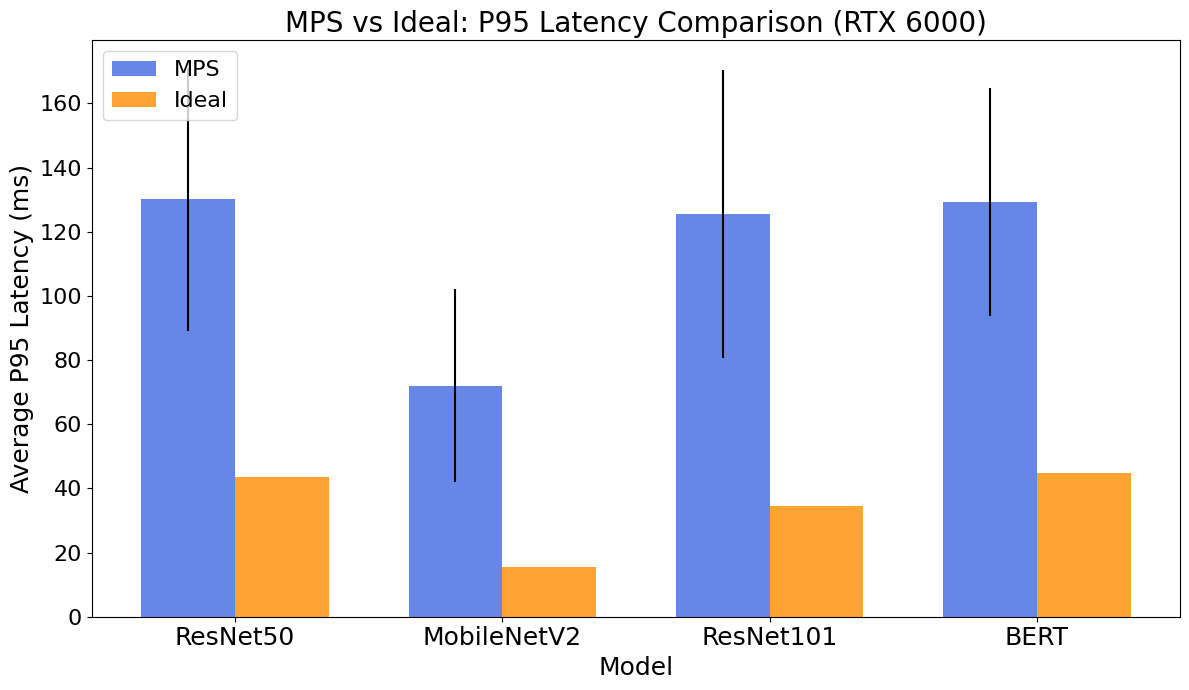

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_vs_ideal_latency.png


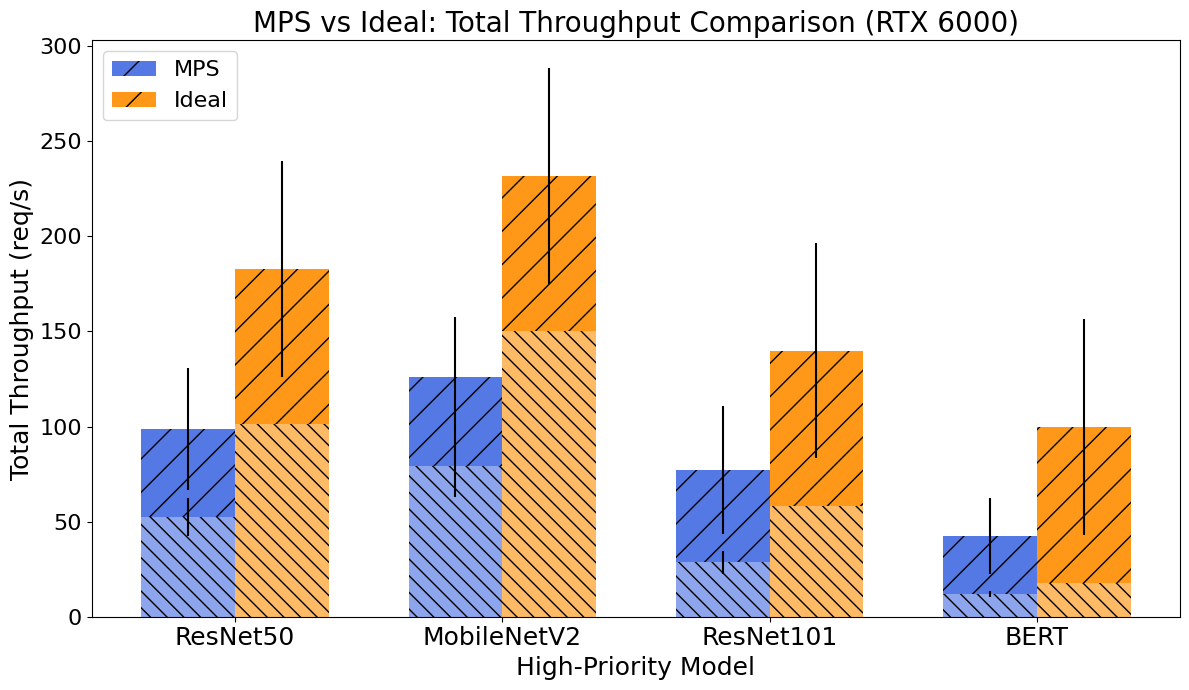

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_vs_ideal_throughput.png


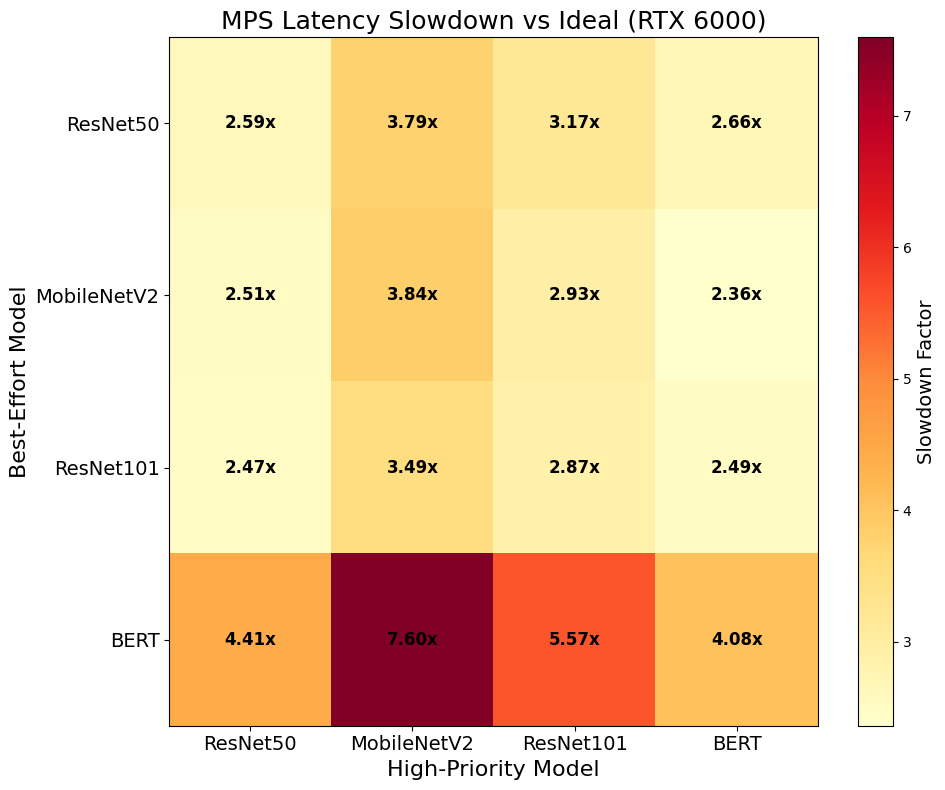

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/results/mps_slowdown_heatmap.png


In [86]:
# Latency comparison: MPS vs Ideal (bars)
colors2 = ['royalblue', 'darkorange']
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(MODELS))

mps_lat_mean = _parse_mean_series(results_dir / 'mps_latency.csv')
mps_lat_std = _parse_std_series(results_dir / 'mps_latency.csv')
ideal_lat_mean = _parse_mean_series(results_dir / 'ideal_latency.csv')
ideal_lat_std = _parse_std_series(results_dir / 'ideal_latency.csv')

ax.bar(x + width * 0, mps_lat_mean.values, width, label='MPS', yerr=mps_lat_std.values, align='edge', color=colors2[0], alpha=0.8)
ax.bar(x + width * 1, ideal_lat_mean.values, width, label='Ideal', yerr=ideal_lat_std.values, align='edge', color=colors2[1], alpha=0.8)

x_tick_positions = x + width
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=16)
ax.set_ylabel('Average P95 Latency (ms)', fontsize=18)
ax.set_xlabel('Model', fontsize=18)
ax.set_title('MPS vs Ideal: P95 Latency Comparison (RTX 6000)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()

out_lat = results_dir / 'mps_vs_ideal_latency.png'
plt.savefig(out_lat, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_lat.resolve())

# Throughput comparison: MPS vs Ideal (stacked)
fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(MODELS))
width = 0.35

mps_be_mean, mps_hp_mean = _parse_mean_pair(results_dir / 'mps_be_throughput.csv', results_dir / 'mps_hp_throughput.csv')
mps_be_std, mps_hp_std = _parse_std_pair(results_dir / 'mps_be_throughput.csv', results_dir / 'mps_hp_throughput.csv')
ideal_be_mean, ideal_hp_mean = _parse_mean_pair(results_dir / 'ideal_be_throughput.csv', results_dir / 'ideal_hp_throughput.csv')
ideal_be_std, ideal_hp_std = _parse_std_pair(results_dir / 'ideal_be_throughput.csv', results_dir / 'ideal_hp_throughput.csv')

# Stack HP bottom then BE top (as in plot_comparison.py)
ax.bar(x + width * 0, mps_hp_mean.values, width, yerr=mps_hp_std.values, align='edge', hatch='\\\\', color=colors2[0], alpha=0.6)
ax.bar(x + width * 0, mps_be_mean.values, width, label='MPS', yerr=mps_be_std.values, bottom=mps_hp_mean.values, align='edge', hatch='/', color=colors2[0], alpha=0.9)

ax.bar(x + width * 1, ideal_hp_mean.values, width, yerr=ideal_hp_std.values, align='edge', hatch='\\\\', color=colors2[1], alpha=0.6)
ax.bar(x + width * 1, ideal_be_mean.values, width, label='Ideal', yerr=ideal_be_std.values, bottom=ideal_hp_mean.values, align='edge', hatch='/', color=colors2[1], alpha=0.9)

x_tick_positions = x + width
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=16)
ax.set_ylabel('Total Throughput (req/s)', fontsize=18)
ax.set_xlabel('High-Priority Model', fontsize=18)
ax.set_title('MPS vs Ideal: Total Throughput Comparison (RTX 6000)', fontsize=20)
plt.legend(loc='upper left', fontsize=16)
plt.tight_layout()

out_thr = results_dir / 'mps_vs_ideal_throughput.png'
plt.savefig(out_thr, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_thr.resolve())

# Slowdown heatmap: MPS latency / Ideal latency
df_mps_lat = pd.read_csv(results_dir / 'mps_latency.csv', index_col=0)
df_ideal_lat = pd.read_csv(results_dir / 'ideal_latency.csv', index_col=0)

slowdown = pd.DataFrame(index=MODELS, columns=MODELS, dtype=float)
for be in MODELS:
    for hp in MODELS:
        mps_val = float(str(df_mps_lat.at[be, hp]).split('/')[0])
        ideal_val = float(str(df_ideal_lat.at[be, hp]).split('/')[0])
        slowdown.at[be, hp] = (mps_val / ideal_val) if ideal_val > 0 else 0.0

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(slowdown.values, cmap='YlOrRd', aspect='auto')

ax.set_xticks(np.arange(len(MODELS)))
ax.set_yticks(np.arange(len(MODELS)))
ax.set_xticklabels(MODELS, fontsize=14)
ax.set_yticklabels(MODELS, fontsize=14)
ax.set_xlabel('High-Priority Model', fontsize=16)
ax.set_ylabel('Best-Effort Model', fontsize=16)
ax.set_title('MPS Latency Slowdown vs Ideal (RTX 6000)', fontsize=18)

for i in range(len(MODELS)):
    for j in range(len(MODELS)):
        ax.text(j, i, f'{slowdown.iloc[i, j]:.2f}x', ha='center', va='center', color='black', fontsize=12, weight='bold')

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Slowdown Factor', fontsize=14)
plt.tight_layout()

out_hm = results_dir / 'mps_slowdown_heatmap.png'
plt.savefig(out_hm, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_hm.resolve())

### Extra: average HP p99 latency and HP throughput
These are averaged across BE models for each HP model (same averaging style as the paper-style p95 plot), and are useful to report tail latency at p99 and the HP-side throughput directly.

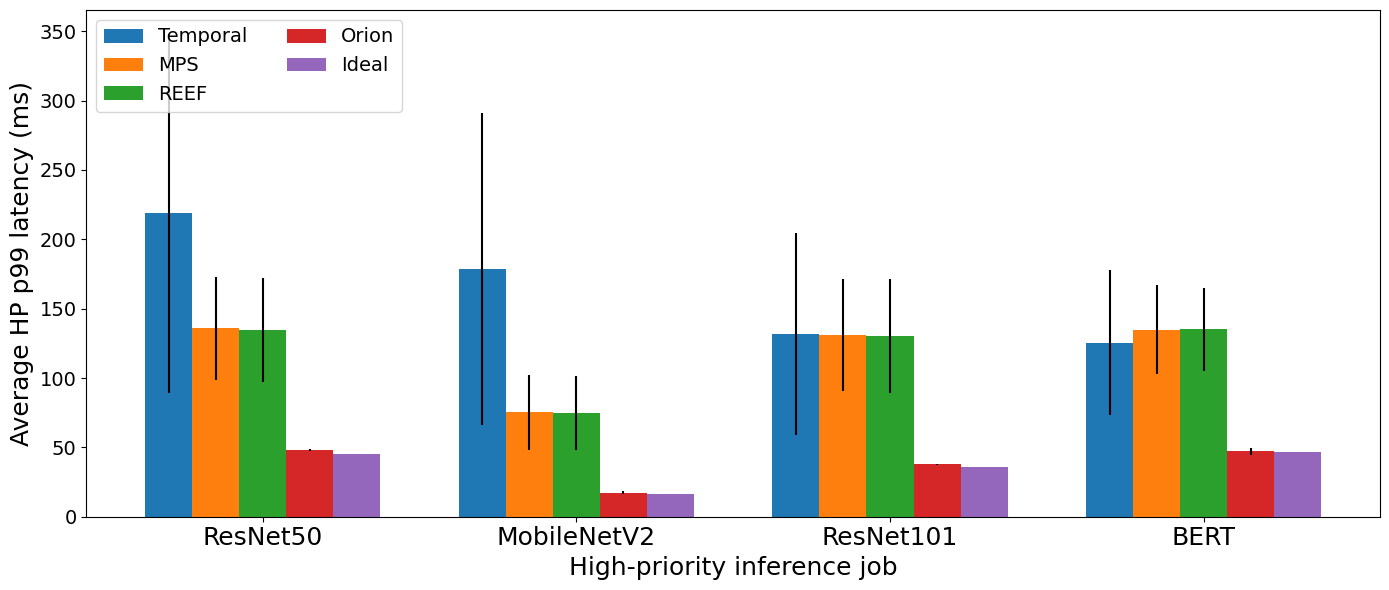

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_p99_latency.png


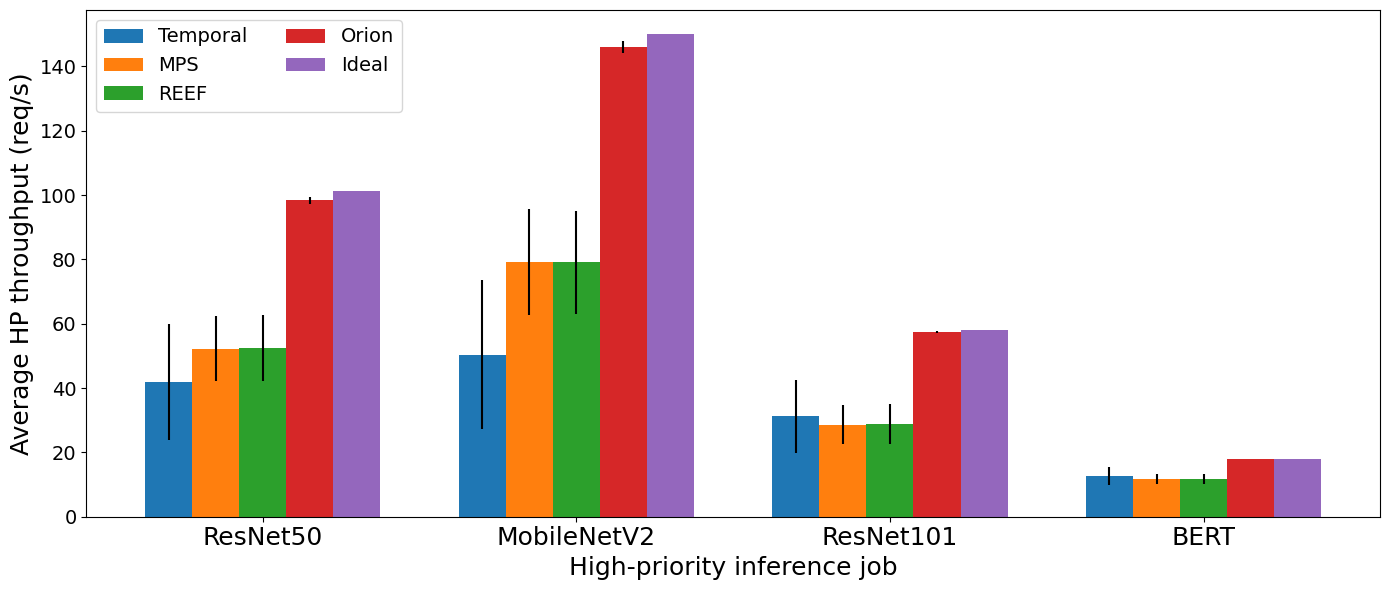

Saved: /home/cc/orion/rtx6000_results/inf_inf_updated/inf_inf_poisson_hp_throughput.png


In [ ]:
def _avg_hp_p99_latency_ms(method: str, runs: list[int] | None = None) -> tuple[np.ndarray, np.ndarray]:
    """Return (mean, std) over BE models for each HP model."""
    if runs is None:
        runs = [0]
    prefix = method2prefix[method]
    means = []
    stds = []
    for hp in MODELS:
        vals = []
        if prefix in {'mps', 'streams'}:
            # files: results/{prefix}/{HP}_{BE}_{run}.json ; idx0 is HP
            for be in MODELS:
                for run in runs:
                    p = results_dir / prefix / f'{hp}_{be}_{run}.json'
                    d = _load_json_maybe(p)
                    if not d:
                        continue
                    v_us = d.get('p99-latency-0')
                    if v_us is None:
                        continue
                    vals.append(float(v_us) * _LAT_US_TO_MS)
        elif prefix == 'ideal':
            # files: results/ideal/{HP}_{run}_hp.json (isolated)
            for p in (results_dir / 'ideal').glob(f'{hp}_*_hp.json'):
                d = _load_json_maybe(p)
                if not d:
                    continue
                v_us = d.get('p99_latency')
                if v_us is None:
                    continue
                vals.append(float(v_us) * _LAT_US_TO_MS)
        else:
            # orion-like: results/{prefix}/{BE}_{HP}_{run}_hp.json
            for be in MODELS:
                for run in runs:
                    p = results_dir / prefix / f'{be}_{hp}_{run}_hp.json'
                    d = _load_json_maybe(p)
                    if not d:
                        continue
                    v_us = d.get('p99_latency')
                    if v_us is None:
                        continue
                    vals.append(float(v_us) * _LAT_US_TO_MS)
        arr = np.array(vals, dtype=float)
        means.append(float(arr.mean()) if len(arr) else float('nan'))
        stds.append(float(arr.std()) if len(arr) else float('nan'))
    return np.array(means), np.array(stds)


def _avg_hp_throughput(method: str) -> tuple[np.ndarray, np.ndarray]:
    """Return (mean, std) over BE models for each HP model from the *_hp_throughput.csv matrices."""
    prefix = method2prefix[method]
    csv_hp = results_dir / f'{prefix}_hp_throughput.csv'
    df = pd.read_csv(csv_hp)
    df = df.drop(df.columns[0], axis=1)
    df.index = MODELS
    for r in MODELS:
        for c in MODELS:
            df.at[r, c] = float(str(df.at[r, c]).split('/')[0])
    mean = df.mean().values
    std = df.std().values
    return mean, std


# --- Plot 1: average HP p99 latency (ms) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25
for method_id, method in enumerate(available_methods):
    mu, sd = _avg_hp_p99_latency_ms(method)
    ax.bar(x + width * method_id, mu, width, yerr=sd, align='edge', label=method)
x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=14)
# ax.set_ylim(0, 120)
ax.set_ylabel('Average HP p99 latency (ms)', fontsize=18)
ax.set_xlabel('High-priority inference job', fontsize=18)
plt.tight_layout()
plt.legend(loc='upper left', ncol=2, fontsize=14)
out_p99 = BASE / 'inf_inf_poisson_hp_p99_latency.png'
plt.savefig(out_p99, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_p99.resolve())

# --- Plot 2: average HP throughput (req/s) ---
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(MODELS))
width = 0.15 if len(available_methods) >= 4 else 0.25
for method_id, method in enumerate(available_methods):
    mu, sd = _avg_hp_throughput(method)
    ax.bar(x + width * method_id, mu, width, yerr=sd, align='edge', label=method)
x_tick_positions = x + width * len(available_methods) / 2
ax.set_xticks(ticks=x_tick_positions, labels=MODELS, fontsize=18)
plt.yticks(fontsize=14)
ax.set_ylabel('Average HP throughput (req/s)', fontsize=18)
ax.set_xlabel('High-priority inference job', fontsize=18)
plt.tight_layout()
plt.legend(loc='upper left', ncol=2, fontsize=14)
out_hp_thr = BASE / 'inf_inf_poisson_hp_throughput.png'
plt.savefig(out_hp_thr, bbox_inches='tight', dpi=300)
plt.show()
print('Saved:', out_hp_thr.resolve())